# Segunda derivada, LoG y detección de bordes de Canny

**Procesamiento de Imágenes — Universidad Diego Portales**

La clase anterior detectó bordes buscando **máximos de la primera derivada**.
Este cuaderno explora la alternativa —buscar **cruces por cero de la segunda
derivada**— y termina con el detector de Canny, que integra casi todo lo visto
en la unidad.


## 0. Preparación

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage import data

print("OpenCV:", cv2.__version__)

plt.rcParams["figure.figsize"] = (10, 4)
plt.rcParams["image.cmap"] = "gray"

img = data.camera()
monedas = data.coins()
color = cv2.cvtColor(data.astronaut(), cv2.COLOR_RGB2BGR)

rng = np.random.default_rng(0)
ruidosa = np.clip(img + rng.normal(0, 20, img.shape), 0, 255).astype(np.uint8)

print("camera:", img.shape, img.dtype)

OpenCV: 4.12.0
camera: (512, 512) uint8


In [2]:
def mostrar(imagenes, titulos=None, cols=None, escala=3.4):
    if isinstance(imagenes, np.ndarray):
        imagenes = [imagenes]
    if titulos is None:
        titulos = [""] * len(imagenes)
    if isinstance(titulos, str):
        titulos = [titulos]

    n = len(imagenes)
    cols = cols or n
    filas = int(np.ceil(n / cols))
    fig, axs = plt.subplots(filas, cols,
                            figsize=(escala * cols, escala * filas * 1.05))
    axs = np.atleast_1d(axs).ravel()
    for ax, im, t in zip(axs, imagenes, titulos):
        if im.ndim == 3:
            ax.imshow(cv2.cvtColor(im, cv2.COLOR_BGR2RGB))
        else:
            ax.imshow(im, cmap="gray", vmin=0, vmax=255)
        ax.set_title(t, fontsize=10); ax.axis("off")
    for ax in axs[n:]:
        ax.axis("off")
    plt.tight_layout(); plt.show()


def mostrar_signo(mapas, titulos=None, cols=None, escala=3.4):
    """Mapas CON SIGNO, con colormap divergente centrado en cero."""
    if isinstance(mapas, np.ndarray):
        mapas = [mapas]
    if titulos is None:
        titulos = [""] * len(mapas)
    if isinstance(titulos, str):
        titulos = [titulos]

    n = len(mapas)
    cols = cols or n
    filas = int(np.ceil(n / cols))
    fig, axs = plt.subplots(filas, cols,
                            figsize=(escala * cols, escala * filas * 1.05))
    axs = np.atleast_1d(axs).ravel()
    for ax, m, t in zip(axs, mapas, titulos):
        # Guarda: con un mapa de 3 canales, imshow lo interpreta como RGB,
        # ignora el colormap y recorta los negativos SIN avisar.
        if m.ndim != 2:
            raise ValueError(f"mostrar_signo espera un mapa 2-D, recibió {m.shape}.")
        lim = np.abs(m).max()
        im = ax.imshow(m, cmap="coolwarm", vmin=-lim, vmax=lim)
        ax.set_title(t, fontsize=10); ax.axis("off")
        fig.colorbar(im, ax=ax, fraction=0.046)
    for ax in axs[n:]:
        ax.axis("off")
    plt.tight_layout(); plt.show()

## 1. Primera contra segunda derivada

Sobre el mismo pulso de la clase anterior, ahora con las dos derivadas:

$$f'(n) \approx \frac{f(n+1)-f(n-1)}{2}
\qquad
f''(n) \approx f(n+1) - 2f(n) + f(n-1)$$

El kernel de la segunda derivada, `[1, -2, 1]`, es la versión 1-D del
laplaciano. Y su suma también es 0.

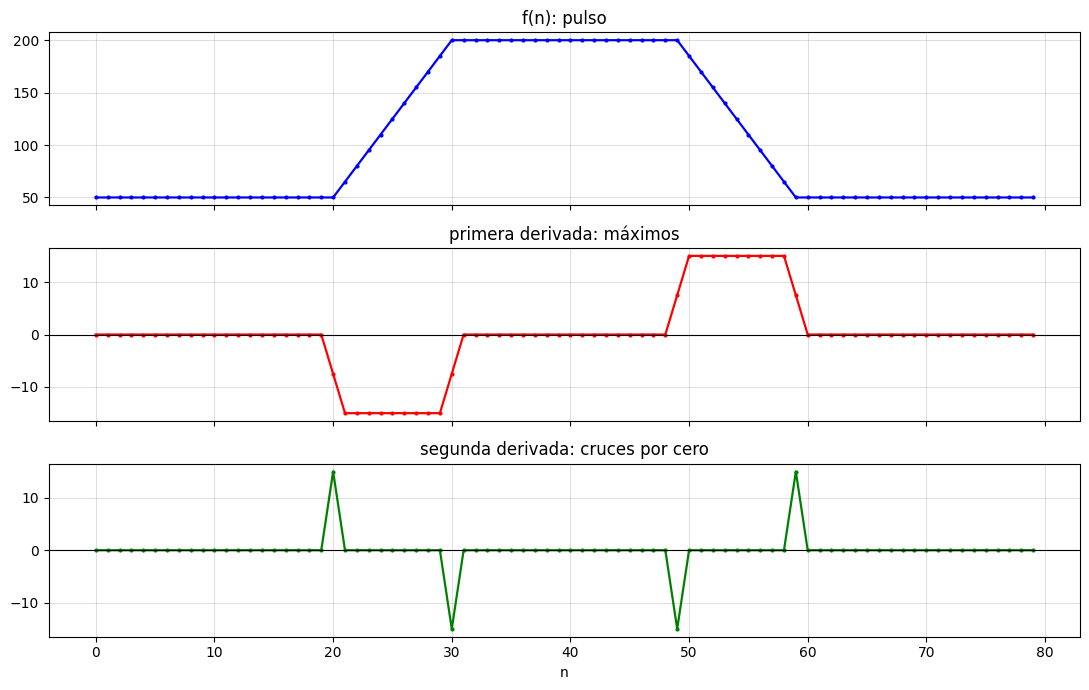

Suma del kernel [1, -2, 1]: 0
Cruces de signo de la 2a derivada en n = [19 20 29 30 48 49 58 59]


In [3]:
n = np.arange(80)
pulso = np.minimum(np.clip(50 + (n - 20) * 15.0, 50, 200),
                   np.clip(50 + (59 - n) * 15.0, 50, 200))


def derivar(s, kernel):
    s_ext = np.pad(s, 1, mode="edge")      # evita flancos falsos en los extremos
    return np.convolve(s_ext, kernel[::-1], mode="valid")


d1 = derivar(pulso, np.array([1, 0, -1]) / 2)
d2 = derivar(pulso, np.array([1, -2, 1]))

fig, axs = plt.subplots(3, 1, figsize=(11, 7), sharex=True)
axs[0].plot(n, pulso, "b.-", lw=1.6, ms=4); axs[0].set_title("f(n): pulso")
axs[1].plot(n, d1, "r.-", lw=1.6, ms=4); axs[1].set_title("primera derivada: máximos")
axs[2].plot(n, d2, "g.-", lw=1.6, ms=4); axs[2].set_title("segunda derivada: cruces por cero")
for ax in axs[1:]:
    ax.axhline(0, color="k", lw=0.8)
for ax in axs:
    ax.grid(True, alpha=0.4)
axs[2].set_xlabel("n")
plt.tight_layout(); plt.show()

print("Suma del kernel [1, -2, 1]:", np.sum([1, -2, 1]))
print("Cruces de signo de la 2a derivada en n =",
      np.where(np.diff(np.sign(d2)) != 0)[0])

### Análisis

Los dos flancos del pulso producen respuestas de forma distinta:

- La **primera derivada** da una meseta por flanco. Para localizar el borde hay
  que buscar el máximo, y el máximo de una meseta es ambiguo: cualquiera de sus
  muestras compite.
- La **segunda derivada** da un par de lóbulos de signo opuesto por flanco, y
  entre ellos un **cruce por cero** en un punto único. Localización más precisa
  y, además, sin tener que elegir un umbral para decidir dónde está la cima.

El precio aparece en las secciones siguientes: la segunda derivada cruza el cero
también donde no hay ningún borde, y amplifica el ruido mucho más.

### Veamos un corte transversal en una imagen de ejemplo.  

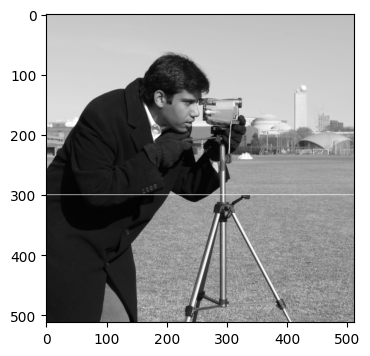

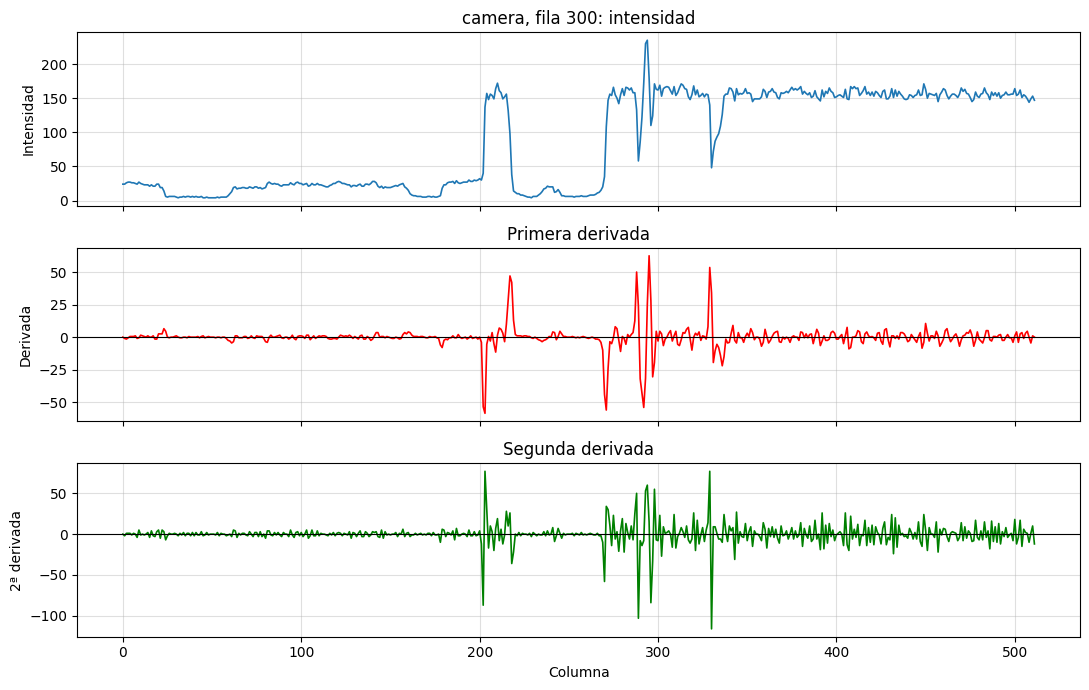

Primera derivada
Máximo positivo: 62.5 en la columna 295
Máximo negativo: -58.5 en la columna 203

Segunda derivada
Máximo positivo: 77.0 en la columna 203
Máximo negativo: -116.0 en la columna 330


In [4]:
# Mostrar la imagen cámara y subrayar la fila que se usará para el perfil
img = data.camera()
fila = 300
img[fila, :] = 255  # subrayar la fila

plt.imshow(img, cmap="gray", vmin=0, vmax=255)
plt.show()

# Volver a cargar la imagen original
img = data.camera()

# Extraer el perfil de intensidad de la fila seleccionada
perfil = img[fila].astype(np.float64)

# Primera derivada: [1, 0, -1] / 2
kernel_1 = np.array([[1, 0, -1]], np.float32) / 2

derivada = cv2.filter2D(
    perfil.reshape(1, -1),
    cv2.CV_64F,
    kernel_1
).ravel()

# Segunda derivada: [-1, 2, -1]
kernel_2 = np.array([[-1, 2, -1]], np.float32)

segunda_derivada = cv2.filter2D(
    perfil.reshape(1, -1),
    cv2.CV_64F,
    kernel_2
).ravel()

# Mostrar perfil, primera y segunda derivada
fig, axs = plt.subplots(3, 1, figsize=(11, 7), sharex=True)

axs[0].plot(perfil, lw=1.2)
axs[0].set_title(f"camera, fila {fila}: intensidad")
axs[0].set_ylabel("Intensidad")

axs[1].plot(derivada, "r-", lw=1.2)
axs[1].axhline(0, color="k", lw=0.8)
axs[1].set_title("Primera derivada")
axs[1].set_ylabel("Derivada")

axs[2].plot(segunda_derivada, "g-", lw=1.2)
axs[2].axhline(0, color="k", lw=0.8)
axs[2].set_title("Segunda derivada")
axs[2].set_xlabel("Columna")
axs[2].set_ylabel("2ª derivada")

for ax in axs:
    ax.grid(True, alpha=0.4)

plt.tight_layout()
plt.show()


# Resultados de la primera derivada
print("Primera derivada")
print("Máximo positivo:", derivada.max().round(1),
      "en la columna", int(np.argmax(derivada)))
print("Máximo negativo:", derivada.min().round(1),
      "en la columna", int(np.argmin(derivada)))


# Resultados de la segunda derivada
print("\nSegunda derivada")
print("Máximo positivo:", segunda_derivada.max().round(1),
      "en la columna", int(np.argmax(segunda_derivada)))
print("Máximo negativo:", segunda_derivada.min().round(1),
      "en la columna", int(np.argmin(segunda_derivada)))

## 2. El laplaciano

En 2-D la segunda derivada se generaliza como la suma de las segundas derivadas
parciales:

$$\nabla^{2} f = \frac{\partial^{2} f}{\partial x^{2}} + \frac{\partial^{2} f}{\partial y^{2}}$$

Discretizando cada término con `[1, -2, 1]` se obtiene el kernel de **4 vecinos**;
si además se incluyen las diagonales, el de **8 vecinos**:

$$\nabla^{2}_{4} = \begin{bmatrix}0&1&0\\1&-4&1\\0&1&0\end{bmatrix}
\qquad
\nabla^{2}_{8} = \begin{bmatrix}1&1&1\\1&-8&1\\1&1&1\end{bmatrix}$$

Un solo kernel, no dos: el laplaciano da **magnitud de cambio pero no
dirección**. Es el precio de su principal virtud, que es ser isótropo.

**Convención de signo**: aquí el centro es negativo, que es la convención de
`cv2.Laplacian`. Muchos textos usan el signo opuesto; da lo mismo mientras sea
consistente, pero afecta el signo del realce de la sección 7.

In [5]:
LAP4 = np.array([[0, 1, 0], [1, -4, 1], [0, 1, 0]], np.float32)
LAP8 = np.array([[1, 1, 1], [1, -8, 1], [1, 1, 1]], np.float32)

for nombre, k in [("4 vecinos", LAP4), ("8 vecinos", LAP8)]:
    print(f"{nombre}: suma = {k.sum():.0f}, rango = {np.linalg.matrix_rank(k)}")

print("\nEl rango 2 significa que el laplaciano NO es separable:")
print("no puede escribirse como producto externo de dos vectores 1-D,")
print("a diferencia del gaussiano, Sobel o el promedio (todos de rango 1).")

4 vecinos: suma = 0, rango = 2
8 vecinos: suma = 0, rango = 2

El rango 2 significa que el laplaciano NO es separable:
no puede escribirse como producto externo de dos vectores 1-D,
a diferencia del gaussiano, Sobel o el promedio (todos de rango 1).


Rango de la respuesta: -1110.0 a 958.0
Media: 0.01  <- kernel de suma 0
Píxeles negativos: 45.6%


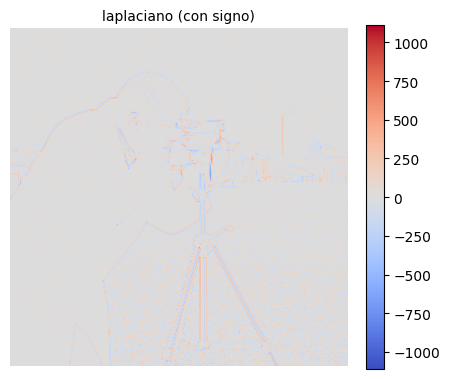

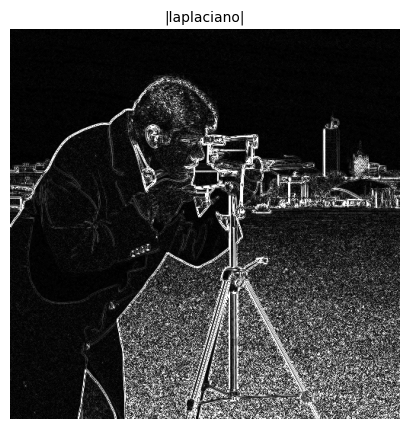

In [6]:
lap = cv2.Laplacian(img, cv2.CV_64F, ksize=3)   # equivale a LAP4

print("Rango de la respuesta:", lap.min(), "a", lap.max())
print("Media:", lap.mean().round(4), " <- kernel de suma 0")
print("Píxeles negativos: %.1f%%" % (100 * (lap < 0).mean()))

mostrar_signo(lap, "laplaciano (con signo)", escala=4.6)
mostrar([cv2.convertScaleAbs(lap)], ["|laplaciano|"], escala=4.2)

### La doble respuesta

Mirar un perfil 1-D de la imagen explica el aspecto de "doble contorno" que
tiene el mapa anterior.

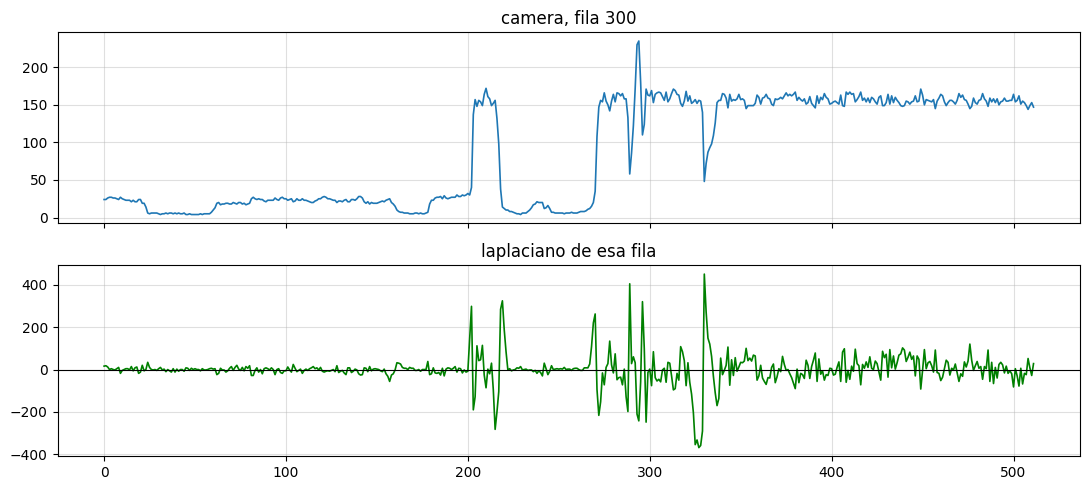

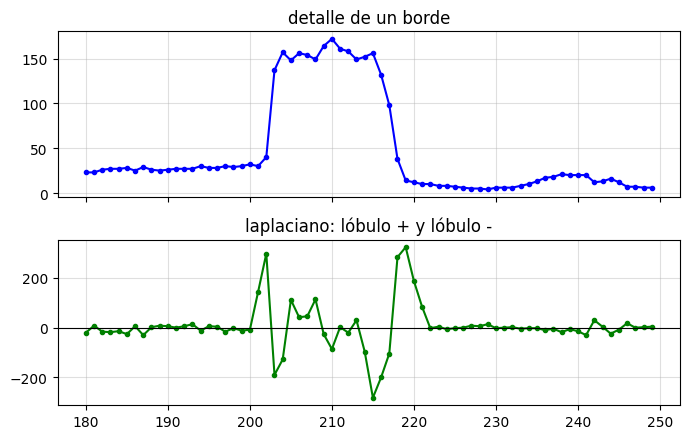

In [7]:
fila = 300
perfil = img[fila].astype(np.float64)
lap_fila = lap[fila]

fig, axs = plt.subplots(2, 1, figsize=(11, 5), sharex=True)
axs[0].plot(perfil, lw=1.2); axs[0].set_title(f"camera, fila {fila}")
axs[1].plot(lap_fila, "g-", lw=1.2); axs[1].axhline(0, color="k", lw=0.8)
axs[1].set_title("laplaciano de esa fila")
for ax in axs:
    ax.grid(True, alpha=0.4)
plt.tight_layout(); plt.show()

# Detalle de un borde concreto
c0, c1 = 180, 250
fig, axs = plt.subplots(2, 1, figsize=(7, 4.5), sharex=True)
axs[0].plot(range(c0, c1), perfil[c0:c1], "b.-")
axs[1].plot(range(c0, c1), lap_fila[c0:c1], "g.-"); axs[1].axhline(0, color="k", lw=0.8)
axs[0].set_title("detalle de un borde"); axs[1].set_title("laplaciano: lóbulo + y lóbulo -")
for ax in axs:
    ax.grid(True, alpha=0.4)
plt.tight_layout(); plt.show()

## 3. El problema del ruido

Derivar una vez amplifica el ruido; derivar dos veces lo amplifica mucho más.
Se mide igual que en la clase anterior: sobre una región plana, donde toda
respuesta es espuria.

Sobel, limpia          respuesta media en zona plana =    15.3
Sobel, ruidosa         respuesta media en zona plana =    92.2
Laplaciano, limpia     respuesta media en zona plana =    12.6
Laplaciano, ruidosa    respuesta media en zona plana =   144.1

Amplificación por el ruido:
  Sobel      : x6.0
  Laplaciano : x11.4


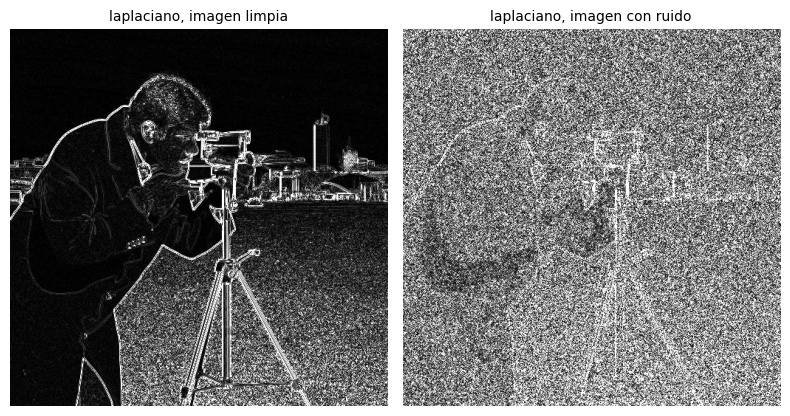

In [8]:
cielo = (slice(0, 120), slice(0, 250))

def magnitud_sobel(im):
    return cv2.magnitude(cv2.Sobel(im, cv2.CV_64F, 1, 0, ksize=3),
                         cv2.Sobel(im, cv2.CV_64F, 0, 1, ksize=3))

med = {
    "Sobel, limpia":       np.abs(magnitud_sobel(img)[cielo]).mean(),
    "Sobel, ruidosa":      np.abs(magnitud_sobel(ruidosa)[cielo]).mean(),
    "Laplaciano, limpia":  np.abs(cv2.Laplacian(img, cv2.CV_64F, ksize=3)[cielo]).mean(),
    "Laplaciano, ruidosa": np.abs(cv2.Laplacian(ruidosa, cv2.CV_64F, ksize=3)[cielo]).mean(),
}
for k, v in med.items():
    print(f"{k:22s} respuesta media en zona plana = {v:7.1f}")

print(f"\nAmplificación por el ruido:")
print(f"  Sobel      : x{med['Sobel, ruidosa'] / med['Sobel, limpia']:.1f}")
print(f"  Laplaciano : x{med['Laplaciano, ruidosa'] / med['Laplaciano, limpia']:.1f}")

mostrar([cv2.convertScaleAbs(cv2.Laplacian(img, cv2.CV_64F, ksize=3)),
         cv2.convertScaleAbs(cv2.Laplacian(ruidosa, cv2.CV_64F, ksize=3))],
        ["laplaciano, imagen limpia", "laplaciano, imagen con ruido"], escala=4.0)

### Análisis

En la zona plana el ruido multiplica la respuesta **por 6 en Sobel y por 11 en
el laplaciano**: casi el doble de sensibilidad. El segundo mapa es prácticamente
ruido puro, y la silueta del camarógrafo apenas se distingue.

La conclusión es fuerte y conviene decirla explícitamente: **el laplaciano crudo
es inutilizable sobre imágenes reales**. No es un filtro que se aplique solo. Lo
que sigue no es una mejora opcional, es lo que lo hace utilizable.

## 4. LoG: laplaciano del gaussiano

La solución es suavizar antes de derivar. Pero en vez de dos convoluciones se
usa una sola, gracias a la **asociatividad de la convolución**:

$$\nabla^{2}\big(G_\sigma * f\big) \;=\; \big(\nabla^{2} G_\sigma\big) * f$$

Derivar el gaussiano es una operación analítica que se hace **una vez**, no por
imagen. El resultado es el kernel **LoG**:

$$\nabla^{2}G_\sigma(x,y) \;=\;
\frac{x^{2}+y^{2}-2\sigma^{2}}{\sigma^{4}}\;
e^{-\frac{x^{2}+y^{2}}{2\sigma^{2}}}$$

Aquí sí importa que la operación sea **convolución** y no correlación: la
asociatividad es una propiedad de la convolución. Como todos los kernels
involucrados son simétricos, en la práctica da lo mismo, pero la demostración
solo es válida para la convolución.

In [9]:
from scipy.signal import convolve2d

sigma = 2.0
k = int(6 * sigma) // 2 * 2 + 1          # regla práctica: ksize ~ 6*sigma+1
g1 = cv2.getGaussianKernel(k, sigma)
G = g1 @ g1.T

f = img.astype(np.float64)

# Camino 1: suavizar y después derivar
camino_1 = cv2.filter2D(cv2.filter2D(f, cv2.CV_64F, G), cv2.CV_64F, LAP4)

# Camino 2: un solo kernel, el LoG
LoG = convolve2d(G, LAP4, mode="full")
camino_2 = cv2.filter2D(f, cv2.CV_64F, LoG)

interior = (slice(20, -20), slice(20, -20))
print("Tamaño del kernel LoG:", LoG.shape, " suma:", round(float(LoG.sum()), 9))
print("Diferencia máxima entre los dos caminos:",
      f"{np.abs(camino_1 - camino_2)[interior].max():.3g}")

Tamaño del kernel LoG: (15, 15)  suma: -0.0
Diferencia máxima entre los dos caminos: 2.07e-12


### Análisis

Los dos caminos coinciden hasta el error de redondeo del `float64`: la
diferencia máxima es del orden de 10⁻¹³. La asociatividad no es una
aproximación, es una identidad.

Esto tiene una consecuencia práctica directa: en vez de dos pasadas (una con un
gaussiano de 13×13 y otra con el laplaciano de 3×3), se hace **una sola** con un
kernel de 15×15 precalculado. Es la primera vez en la unidad que una propiedad
algebraica de la convolución se traduce en un ahorro concreto.

Nótese también que la suma del kernel LoG es 0, como corresponde: sigue siendo
un pasaaltos.

Tamaño: (13, 13)  suma: -0.0


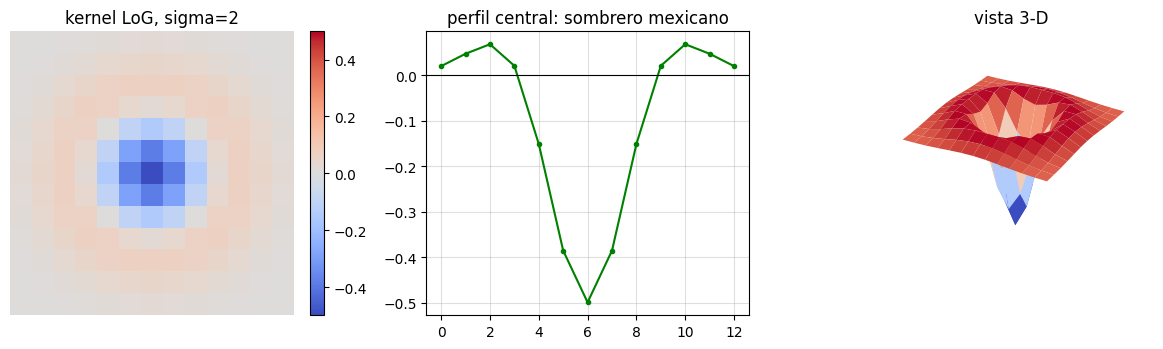

In [10]:
def kernel_LoG(sigma, ksize=None):
    """LoG analítico, normalizado a suma cero."""
    ksize = ksize or int(6 * sigma) // 2 * 2 + 1
    r = ksize // 2
    x, y = np.meshgrid(np.arange(-r, r + 1), np.arange(-r, r + 1))
    r2 = x ** 2 + y ** 2
    L = (r2 - 2 * sigma ** 2) / sigma ** 4 * np.exp(-r2 / (2 * sigma ** 2))
    return L - L.mean()          # fuerza suma 0 pese al truncamiento


L = kernel_LoG(2.0)
print("Tamaño:", L.shape, " suma:", round(float(L.sum()), 12))

fig = plt.figure(figsize=(12, 3.6))
ax1 = fig.add_subplot(1, 3, 1)
im = ax1.imshow(L, cmap="coolwarm", vmin=-np.abs(L).max(), vmax=np.abs(L).max())
ax1.set_title("kernel LoG, sigma=2"); ax1.axis("off"); fig.colorbar(im, ax=ax1, fraction=0.046)

ax2 = fig.add_subplot(1, 3, 2)
ax2.plot(L[L.shape[0] // 2], "g.-"); ax2.axhline(0, color="k", lw=0.8)
ax2.set_title("perfil central: sombrero mexicano"); ax2.grid(True, alpha=0.4)

ax3 = fig.add_subplot(1, 3, 3, projection="3d")
xx, yy = np.meshgrid(range(L.shape[1]), range(L.shape[0]))
ax3.plot_surface(xx, yy, L, cmap="coolwarm", linewidth=0)
ax3.set_title("vista 3-D"); ax3.set_axis_off()
plt.tight_layout(); plt.show()

### Análisis

La forma explica el nombre: un lóbulo central negativo rodeado de un anillo
positivo, el **sombrero mexicano**. Y explica también el comportamiento del
filtro: responde al máximo cuando la estructura de la imagen coincide con el
tamaño del lóbulo central. Es decir, el LoG es un **detector sintonizado a una
escala**, no un detector de bordes genérico. Sigma es esa sintonía.

sigma=1: tamaño del kernel (7, 7), desviación de la respuesta   48.21
sigma=2: tamaño del kernel (13, 13), desviación de la respuesta   63.03
sigma=4: tamaño del kernel (25, 25), desviación de la respuesta   69.37
sigma=8: tamaño del kernel (49, 49), desviación de la respuesta   79.53
sigma=16: tamaño del kernel (97, 97), desviación de la respuesta   97.85


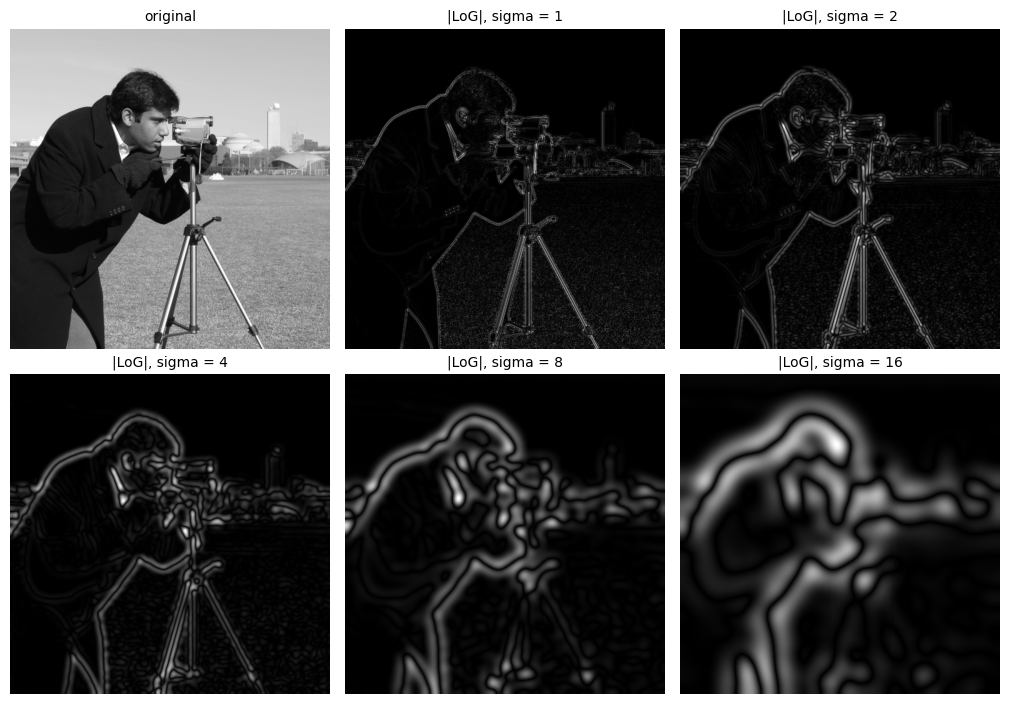

In [11]:
img = data.camera()
#img = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
f = img.astype(np.float64)

salidas, titulos = [img], ["original"]
for s in [1, 2, 4, 8, 16]:
    r = cv2.filter2D(f, cv2.CV_64F, kernel_LoG(s))
    salidas.append(cv2.normalize(np.abs(r), None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8))
    titulos.append(f"|LoG|, sigma = {s}")
    print(f"sigma={s}: tamaño del kernel {kernel_LoG(s).shape}, "
          f"desviación de la respuesta {r.std():7.2f}")

mostrar(salidas, titulos, cols=3, escala=3.4)

## 5. DoG: diferencia de gaussianas

El LoG puede aproximarse restando dos gaussianos de sigma parecido:

$$\text{DoG} = G_{\sigma} * f - G_{k\sigma} * f \;\approx\; -\,\nabla^{2}G_{\sigma} * f$$

Es más barato (dos gaussianos separables en vez de un kernel 2-D grande) y es la
base del detector de puntos de interés de SIFT.

La pregunta natural es qué razón $k$ usar. El valor clásico es 1.6.

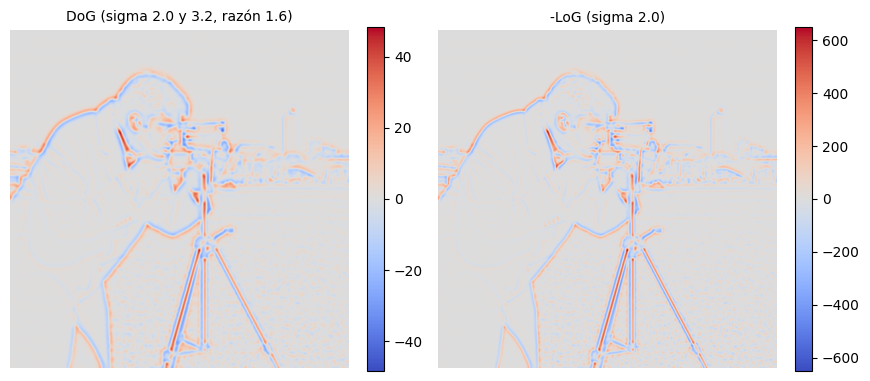

In [12]:
mostrar_signo([cv2.GaussianBlur(f, (0, 0), 2.0) - cv2.GaussianBlur(f, (0, 0), 3.2),
               -cv2.filter2D(f, cv2.CV_64F, kernel_LoG(2.0))],
              ["DoG (sigma 2.0 y 3.2, razón 1.6)", "-LoG (sigma 2.0)"],
              escala=4.4)

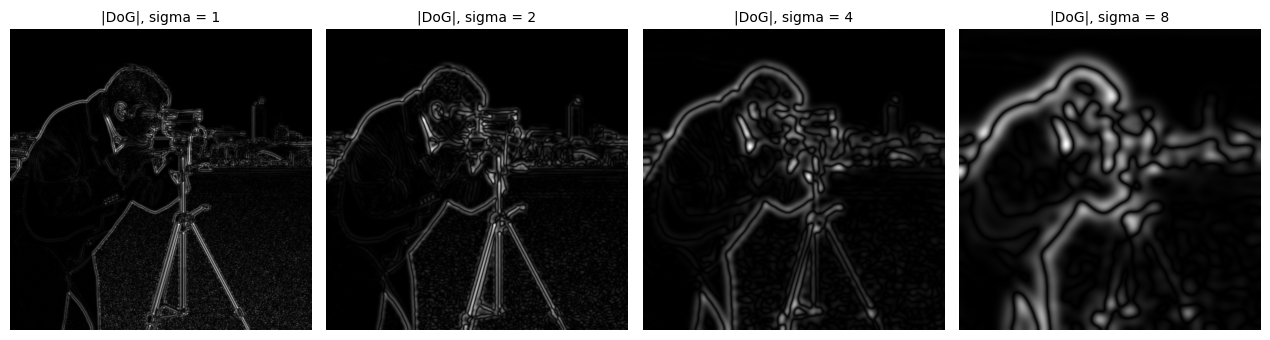

In [13]:
# Espacio de escalas: la misma imagen vista a distintas escalas
octavas = [1, 2, 4, 8]
salidas, titulos = [], []
for s in octavas:
    dog = cv2.GaussianBlur(f, (0, 0), s) - cv2.GaussianBlur(f, (0, 0), s * 1.6)
    salidas.append(cv2.normalize(np.abs(dog), None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8))
    titulos.append(f"|DoG|, sigma = {s}")

mostrar(salidas, titulos, cols=4, escala=3.2)

### Análisis

Cada escala responde a estructuras de un tamaño distinto: las hojas de pasto en
sigma 1, la cámara y la cabeza en sigma 4, la silueta completa en sigma 8. Nada
en la imagen dice cuál es "la" escala correcta, porque no existe: **la escala es
un parámetro de la pregunta, no de la imagen**.

Esa es la idea que SIFT lleva al extremo: en vez de elegir una escala, calcula
todas y busca los puntos que son extremos **también en la dirección de la
escala**, lo que da descriptores invariantes al tamaño del objeto.

## 6. Cruces por cero (Marr–Hildreth)

Con el LoG calculado, el borde está donde la respuesta **cambia de signo**. La
detección compara cada píxel con sus vecinos opuestos en las cuatro direcciones
y marca los cambios de signo.

Un detalle crítico: hay que exigir además una **diferencia mínima de magnitud**.
Sin ese requisito, cualquier fluctuación diminuta alrededor de cero cuenta como
borde.

In [14]:
def cruces_por_cero(L, factor=0.0):
    """Marca los cambios de signo de L.

    factor: umbral relativo, expresado en desviaciones estándar de L.
            Con 0 se marca todo cambio de signo, por pequeño que sea.
    """
    signo = np.sign(L)
    umbral = factor * np.std(L)
    salida = np.zeros(L.shape, np.uint8)

    for dy, dx in [(0, 1), (1, 0), (1, 1), (1, -1)]:
        s_a = np.roll(np.roll(signo, dy, 0), dx, 1)
        s_b = np.roll(np.roll(signo, -dy, 0), -dx, 1)
        v_a = np.roll(np.roll(L, dy, 0), dx, 1)
        v_b = np.roll(np.roll(L, -dy, 0), -dx, 1)
        salida |= ((s_a * s_b < 0) & (np.abs(v_a - v_b) > umbral)).astype(np.uint8)

    # np.roll ENVUELVE la imagen: compara la última fila con la primera y
    # genera un marco de bordes falsos. Se descarta el borde exterior.
    salida[0, :] = salida[-1, :] = salida[:, 0] = salida[:, -1] = 0

    return salida * 255

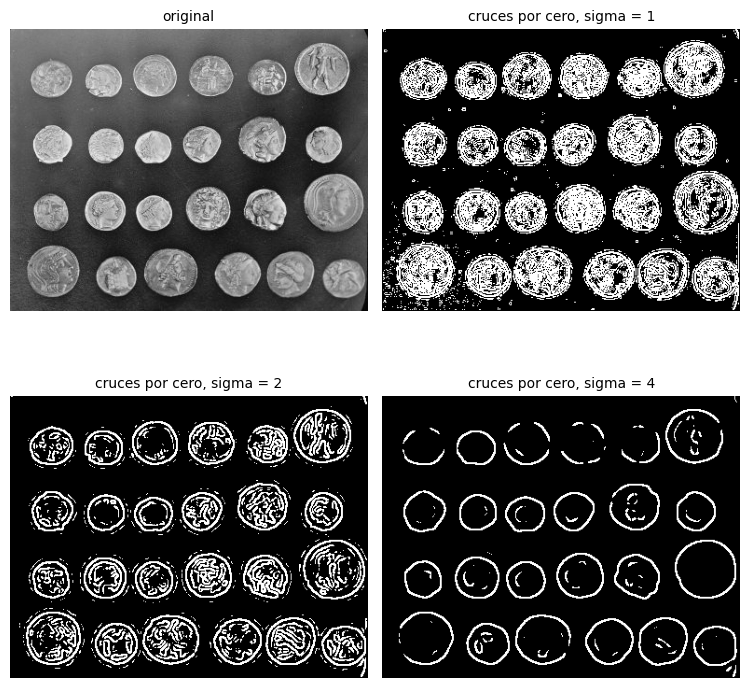

In [15]:
img = data.coins()
#img = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
f = img.astype(np.float64)

salidas, titulos = [img], ["original"]
for s in [1, 2, 4]:
    L_s = cv2.filter2D(f, cv2.CV_64F, kernel_LoG(s))
    salidas.append(cruces_por_cero(L_s, 1.0))
    titulos.append(f"cruces por cero, sigma = {s}")

mostrar(salidas, titulos, cols=2, escala=3.8)

## 8. El detector de Canny

Canny (1986) no introduce un operador nuevo: **integra lo que ya vimos** y agrega
dos ideas. Los cuatro pasos son:

1. **Suavizado gaussiano** — clase de pasabajos.
2. **Gradiente con Sobel**: magnitud y orientación — clase anterior.
3. **Supresión de no máximos**: adelgazar cada borde a un píxel.
4. **Doble umbral con histéresis**: decidir qué es borde.

Los pasos 3 y 4 son las ideas nuevas, y cada uno responde a un problema concreto
que dejamos abierto: los bordes gruesos y la arbitrariedad del umbral.

Canny derivó su detector de **tres criterios explícitos**: buena detección (pocos
falsos positivos y negativos), buena localización (el borde marcado cerca del
borde real) y respuesta única (un solo píxel por borde). Es un diseño derivado de
una formulación, no ajustado por prueba y error, y por eso sigue vigente.

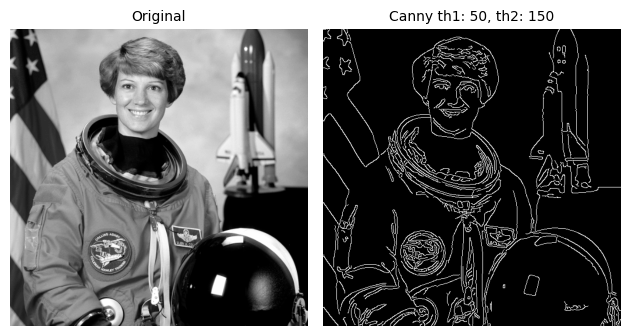

In [29]:
img = data.astronaut()
img = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
umbral_bajo, umbral_alto = 50, 150

imagen_suave = cv2.GaussianBlur(img, (5, 5), 0)
bordes_canny = cv2.Canny(imagen_suave, umbral_bajo, umbral_alto)

mostrar([img, bordes_canny],
        ["Original", f"Canny th1: {umbral_bajo}, th2: {umbral_alto}"],
        cols=2, escala=3.2)

## 9. Comparación final

Los tres enfoques de la unidad sobre la misma imagen.


--- img1 ---


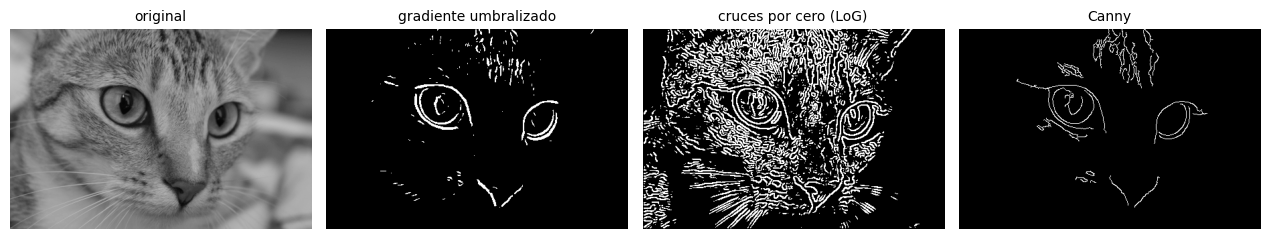


--- img2 ---


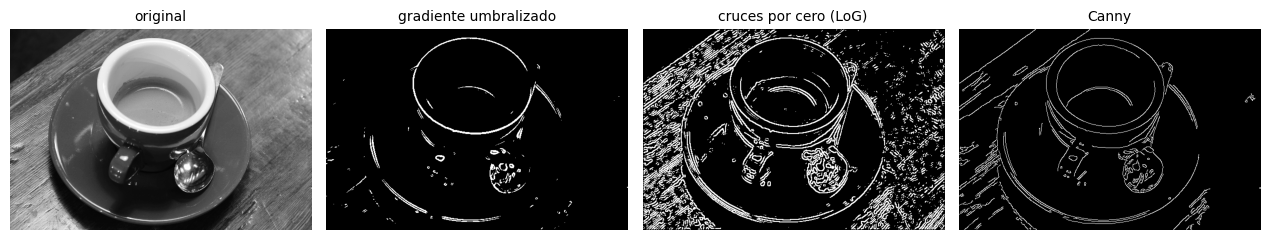

In [32]:
def gradiente_umbralizado(im, percentil=97.5):
    m = magnitud_sobel(cv2.GaussianBlur(im, (5, 5), 0))
    return ((m > np.percentile(m, percentil)) * 255).astype(np.uint8)


def marr_hildreth(im, sigma=2.0, factor=1.0):
    L_s = cv2.filter2D(im.astype(np.float64), cv2.CV_64F, kernel_LoG(sigma))
    return cruces_por_cero(L_s, factor)


img1 = data.chelsea()
img1 = cv2.cvtColor(img1, cv2.COLOR_RGB2GRAY)
img2 = data.coffee()
img2 = cv2.cvtColor(img2, cv2.COLOR_RGB2GRAY)


for nombre, imagen in [("img1", img1), ("img2", img2)]:
    print(f"\n--- {nombre} ---")
    metodos = [imagen,
               gradiente_umbralizado(imagen),
               marr_hildreth(imagen),
               cv2.Canny(cv2.GaussianBlur(imagen, (5, 5), 0), 50, 200)]
    titulos = ["original", "gradiente umbralizado",
               "cruces por cero (LoG)", "Canny"]
    mostrar(metodos, titulos, cols=4, escala=3.2)